

# Part III — NLP (Tweet Sentiment Analysis)

The Vision section above is fully self-contained.  Below is the complete
NLP pipeline (Section 4.5 of the brief).

The NLP loader will use a CSV at `data/financial_phrase.csv` if you provide one;
otherwise it falls back to the bundled NLTK `twitter_samples` corpus so
the notebook always runs end-to-end.


## Environment Setup

In [34]:
# CELL 1 — Install / verify required packages
# Notes:
#   • gensim is NOT pre-installed on Colab; we install it explicitly.
#   • numpy is pinned to a gensim-compatible version (see assessment appendix).
import sys, subprocess

def pip_install(pkg):
    # Use %pip so the install always lands in the active Jupyter kernel
    get_ipython().run_line_magic("pip", f"install -q {pkg}")

# Only install if not already present (keeps re-runs fast)
for pkg in ["nltk", "wordcloud", "gensim", "gradio"]:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        print(f"Installing {pkg} …")
        pip_install(pkg)

print(" Packages ready.")


 Packages ready.


In [35]:
# CELL 2 — Imports & global configuration
import os
import re
import string
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
# Without this, TF reserves ~90% of GPU VRAM up front. Adam's
# embedding-gradient scatter (ResourceScatterAdd) then can't get
# a contiguous chunk and raises OOM even though the model itself
# is small. Memory growth makes TF allocate on demand.
# Must be set BEFORE any TF op runs on the GPU.
gpus = tf.config.list_physical_devices("GPU")
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception as e:
        print(f"  could not set memory growth on {g}: {e}")
print(f"GPU memory growth enabled on {len(gpus)} device(s).")

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional,
    SpatialDropout1D
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report
)

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Download required NLTK resources (idempotent). twitter_samples removed —
# this notebook is for Financial PhraseBank only.
for r in ["stopwords", "wordnet", "punkt", "punkt_tab",
          "averaged_perceptron_tagger", "omw-1.4"]:
    try:
        nltk.download(r, quiet=True)
    except Exception:
        pass

print("TensorFlow :", tf.__version__)
print("GPU avail. :", bool(gpus))


GPU memory growth enabled on 1 device(s).
TensorFlow : 2.10.0
GPU avail. : True



## 4.5.1 — Text Preprocessing, Tokenization & Sequence Padding

### Step 1 — Load the dataset

The brief assigns each group a financial-phrase classification dataset. We use the
**Financial PhraseBank** (Malo et al., 2014) — short news headlines and analyst
sentences labelled by domain experts as `negative`, `neutral`, or `positive`.

The CSV `financial_phrase.csv` (columns `text`, `label`) lives next to this notebook.


In [36]:
# CELL 3 — Load the Financial PhraseBank CSV
# Columns expected: 'text', 'label' (label ∈ {negative, neutral, positive}).
# The loader is intentionally strict — if the CSV is missing or malformed we
# raise immediately rather than silently falling back to a different dataset.
def load_data():
    """Return a DataFrame with columns ['text', 'label'] for Financial PhraseBank.

    Searches a small list of plausible locations so the notebook works on
    Windows, WSL, and Colab without code changes.
    """
    candidate_paths = [
        "financial_phrase.csv",                                            # CWD
        "data/financial_phrase.csv",                                       # data/ subfolder
        "/mnt/d/IT/it2026 6th sem/ml ai/assesment/financial_phrase.csv",   # WSL absolute
        r"D:\IT\it2026 6th sem\ml ai\assesment\financial_phrase.csv", # Windows absolute
    ]

    for path in candidate_paths:
        if os.path.exists(path):
            df = pd.read_csv(path)
            df = df.rename(columns={c: c.lower() for c in df.columns})
            if not {"text", "label"}.issubset(df.columns):
                raise ValueError(
                    f"{path} found but missing required columns 'text' / 'label'. "
                    f"Got: {list(df.columns)}"
                )
            df["label"] = df["label"].astype(str).str.strip().str.lower()
            valid = {"positive", "negative", "neutral"}
            df = df[df["label"].isin(valid)].copy()
            df = df[["text", "label"]].dropna().reset_index(drop=True)
            print(f"Loaded {len(df):,} rows from {path}")
            return df

    raise FileNotFoundError(
        "financial_phrase.csv not found. Place it next to this notebook "
        "or in a data/ subfolder. Searched: " + ", ".join(candidate_paths)
    )

df_raw = load_data()
print("\nClass distribution:")
print(df_raw["label"].value_counts())
df_raw.head()


Loaded 2,264 rows from D:\IT\it2026 6th sem\ml ai\assesment\financial_phrase.csv

Class distribution:
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


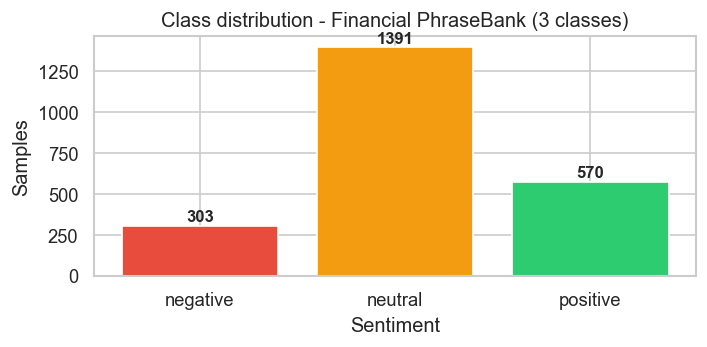

Total samples : 2,264
  Positive  : 570  (25.2%)
  Negative  : 303  (13.4%)
  Neutral   : 1,391  (61.4%)


In [37]:
# CELL 4 — Visualise the raw class distribution (3 classes)
label_counts = df_raw['label'].value_counts().sort_index()

palette = {'negative': '#E74C3C', 'neutral': '#F39C12', 'positive': '#2ECC71'}
colors  = [palette.get(l, '#95a5a6') for l in label_counts.index]

plt.figure(figsize=(6, 3))
bars = plt.bar(label_counts.index, label_counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Class distribution - Financial PhraseBank (3 classes)')
plt.ylabel('Samples'); plt.xlabel('Sentiment')
plt.tight_layout(); plt.show()

print(f'Total samples : {len(df_raw):,}')
for lbl in ['positive', 'negative', 'neutral']:
    n = (df_raw.label == lbl).sum()
    print(f'  {lbl.capitalize():10s}: {n:,}  ({n/len(df_raw):.1%})')


### Step 2 — Text cleaning

We apply the steps required by the brief:

* lowercase the text,
* remove URLs, `@mentions`, `#hashtags`, numbers and special characters,
* expand common contractions (`don't → do not`),
* remove stopwords,
* lemmatize tokens to their base form.

In [38]:
# CELL 5 — Cleaning utilities
# IMPORTANT: For sentiment we keep negation/intensifier words even
# though NLTK lists them as stopwords. Removing 'not', 'no', 'never'
# would flip the meaning of 'no profits' → 'profit'.
CONTRACTIONS = {
    "don't": "do not",  "doesn't": "does not", "didn't": "did not",
    "won't": "will not","wouldn't":"would not","can't": "cannot",
    "couldn't":"could not","shouldn't":"should not","isn't":"is not",
    "aren't":"are not", "wasn't":"was not",  "weren't":"were not",
    "haven't":"have not","hasn't":"has not","hadn't":"had not",
    "i'm":"i am", "you're":"you are","he's":"he is","she's":"she is",
    "it's":"it is","we're":"we are","they're":"they are",
    "i've":"i have","you've":"you have","we've":"we have","they've":"they have",
    "i'll":"i will","you'll":"you will","he'll":"he will","she'll":"she will",
    "we'll":"we will","they'll":"they will",
    "i'd":"i would","you'd":"you would","he'd":"he would","she'd":"she would",
    "we'd":"we would","they'd":"they would",
    "ain't":"is not",
    "let's":"let us", "that's":"that is","what's":"what is",
}

URL_RE     = re.compile(r"https?://\S+|www\.\S+")
NUM_RE     = re.compile(r"\d+")
NONALPHA_RE= re.compile(r"[^a-z\s]")

# Remove negation/intensifier words from the stopword list — these are
# critical signal-bearing tokens for financial sentiment.
KEEP_WORDS = {
    'no', 'not', 'nor', 'never', 'neither', 'none', 'nothing',
    'without', 'cannot', 'against', 'but', 'however',
    'very', 'too', 'so', 'just', 'only', 'more', 'most', 'less', 'few',
    'up', 'down', 'over', 'under', 'above', 'below'
}
STOPWORDS  = set(stopwords.words("english")) - KEEP_WORDS
LEMMATIZER = WordNetLemmatizer()

def expand_contractions(text):
    for c, full in CONTRACTIONS.items():
        text = text.replace(c, full)
    return text

def clean_text(text: str) -> str:
    '''Apply the full cleaning pipeline to a single financial sentence.'''
    text = text.lower()
    text = URL_RE.sub("", text)
    text = expand_contractions(text)
    text = NUM_RE.sub("", text)
    text = NONALPHA_RE.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    # Lemmatise as NOUN first, then VERB — collapses 'losses'→'loss'
    # AND 'widened'→'widen' so both forms map to the same vocab entry.
    tokens = [
        LEMMATIZER.lemmatize(LEMMATIZER.lemmatize(t, pos='n'), pos='v')
        for t in tokens
        if t not in STOPWORDS and len(t) > 1
    ]
    return " ".join(tokens)

# Sanity checks on financial-style sentences — note negations are preserved
for s in [
    "Operating profit rose to EUR 14.5 mn from EUR 9.2 mn a year earlier.",
    "The company did not report any profits this quarter.",
    "Losses widened significantly as revenues collapsed.",
]:
    print(f'IN : {s}')
    print(f'OUT: {clean_text(s)}\n')


IN : Operating profit rose to EUR 14.5 mn from EUR 9.2 mn a year earlier.
OUT: operate profit rise eur mn eur mn year earlier

IN : The company did not report any profits this quarter.
OUT: company not report profit quarter

IN : Losses widened significantly as revenues collapsed.
OUT: loss widen significantly revenue collapse



In [39]:
# CELL 6 — Apply cleaning to the whole corpus
print("Applying cleaning to all texts …")
df = df_raw.copy()
df["clean_text"] = df["text"].astype(str).apply(clean_text)
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)
print(f"Rows after cleaning : {len(df):,}")
df[["text", "clean_text", "label"]].head()


Applying cleaning to all texts …
Rows after cleaning : 2,264


,text,clean_text,label
0,"According to Gran , the company has no plans t...",accord gran company no plan move production ru...,neutral
1,"For the last quarter of 2010 , Componenta 's n...",last quarter componenta net sale double eurm e...,positive
2,"In the third quarter of 2010 , net sales incre...",third quarter net sale increase eur mn operate...,positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,operate profit rise eur mn eur mn correspond p...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",operate profit total eur mn up eur mn represen...,positive


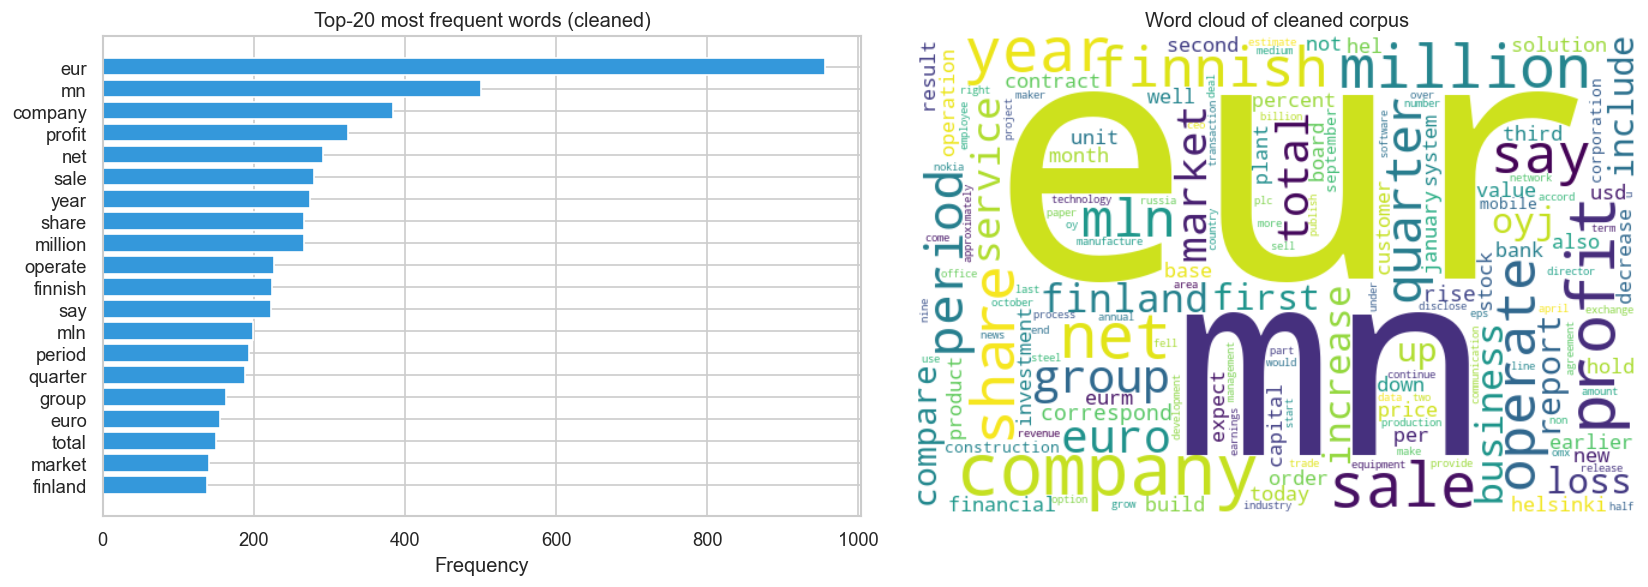

Vocabulary size (unique tokens): 4,286


In [40]:
# CELL 7 — Visualise the cleaned vocabulary
from collections import Counter
from wordcloud import WordCloud

all_tokens = " ".join(df["clean_text"]).split()
counter    = Counter(all_tokens)
top20      = counter.most_common(20)

# Plot bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh([w for w, _ in top20][::-1],
             [c for _, c in top20][::-1], color="#3498DB")
axes[0].set_title("Top-20 most frequent words (cleaned)")
axes[0].set_xlabel("Frequency")

# Word cloud
wc = WordCloud(width=600, height=400, background_color="white",
               max_words=150, colormap="viridis").generate_from_frequencies(counter)
axes[1].imshow(wc, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Word cloud of cleaned corpus")
plt.tight_layout(); plt.show()

print(f"Vocabulary size (unique tokens): {len(counter):,}")


### Step 3 — Train/test split, tokenisation & padding

* **Split**: 80 % train / 20 % test (stratified by label).
* **Tokenisation**: `keras.Tokenizer` with vocabulary capped at 10 000 most-frequent words.
* **Padding**: percentile-based — sequences are padded/truncated to the **95th-percentile token-count** of the cleaned training corpus.  This avoids wasting compute on a few extremely long outliers.

Unique labels in df["label"]: ['neutral' 'positive' 'negative']
Total rows in df: 2264

Rows after valid-label filter: 2264 / 2264
Label distribution after mapping:
  negative   (0) : 303  (13.4%)
  neutral    (1) : 1,391  (61.4%)
  positive   (2) : 570  (25.2%)

Training samples : 1,811
Test     samples : 453
95th-percentile sequence length → MAX_LEN = 23
X_train shape : (1811, 23)
X_test  shape : (453, 23)


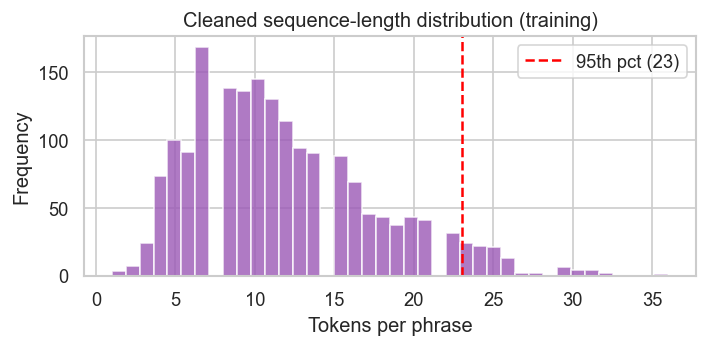

Effective vocabulary size : 3,857


In [41]:
# CELL 8 — Train/test split + tokenisation + percentile padding
#          3-class: negative=0  neutral=1  positive=2
X_text = df['clean_text'].values
# DIAGNOSTIC: inspect actual label values before mapping
print('Unique labels in df["label"]:', df['label'].unique())
print('Total rows in df:', len(df))

# Normalise to lowercase to handle capitalisation differences
df['label_norm'] = df['label'].astype(str).str.strip().str.lower()

# Added '0', '1', '2' to handle datasets where labels are already numeric integers
label_map = {
    'negative': 0, '0': 0,
    'neutral': 1,  '1': 1,
    'positive': 2, '2': 2
}
NUM_CLASSES = 3

y_series = df['label_norm'].map(label_map)
valid = y_series.notna()

print(f'\nRows after valid-label filter: {valid.sum()} / {len(df)}')
if valid.sum() == 0:
    raise ValueError(
        f"No rows survived label mapping. "
        f"Actual labels found: {df['label'].unique().tolist()}. "
        f"Expected one of: {list(label_map.keys())}"
    )

X_text = X_text[valid]
y = y_series[valid].astype(int).values

print('Label distribution after mapping:')
class_names = {0: 'negative', 1: 'neutral', 2: 'positive'}
for code in sorted(set(y)):
    n = (y == code).sum()
    name = class_names.get(code, f"unknown")
    print(f'  {name:10s} ({code}) : {n:,}  ({n/len(y):.1%})')

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED,
)
print(f'\nTraining samples : {len(X_train_text):,}')
print(f'Test     samples : {len(X_test_text):,}')
VOCAB_SIZE = 10_000
OOV_TOKEN = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)
seq_lens = [len(s) for s in X_train_seq]
MAX_LEN = int(np.percentile(seq_lens, 95))
print(f'95th-percentile sequence length → MAX_LEN = {MAX_LEN}')

X_train = pad_sequences(X_train_seq, maxlen=MAX_LEN,
                        padding='post', truncating='post')
X_test = pad_sequences(X_test_seq, maxlen=MAX_LEN,
                       padding='post', truncating='post')

print('X_train shape :', X_train.shape)
print('X_test  shape :', X_test.shape)

# Plot length distribution
plt.figure(figsize=(6, 3))
plt.hist(seq_lens, bins=40, color='#9B59B6', alpha=0.8)
plt.axvline(MAX_LEN, color='red', linestyle='--',
            label=f'95th pct ({MAX_LEN})')
plt.xlabel('Tokens per phrase')
plt.ylabel('Frequency')
plt.title('Cleaned sequence-length distribution (training)')
plt.legend()
plt.tight_layout()
plt.show()

# Vocabulary actually used
word_index = tokenizer.word_index
vocab_size = min(VOCAB_SIZE, len(word_index) + 1)
print(f'Effective vocabulary size : {vocab_size:,}')



## 4.5.2 — Model Building and Training

Three models, all evaluated on the same 80/20 train/test split (3-class: Negative / Neutral / Positive):

| # | Architecture | Embedding | Recurrent layer |
|---|--------------|-----------|------------------|
| 1 | **Bidirectional SimpleRNN**              | trainable | `Bidirectional(SimpleRNN(64))`  |
| 2 | **BiLSTM + SpatialDropout**              | trainable | `Bidirectional(LSTM(64))`        |
| 3 | **BiLSTM + GloVe (fine-tuned)**          | GloVe-100d | 2-phase frozen → fine-tune      |

All models share a `Dense(64, relu) → Dropout → Dense(NUM_CLASSES, softmax)` head and
are trained with `sparse_categorical_crossentropy`, sqrt-smoothed class weights,
EarlyStopping and ReduceLROnPlateau on validation loss.


In [42]:
# CELL 9 — Shared training configuration
# Class-weight strategy: SQRT-smoothed inverse frequency.
#   Full 'balanced' weights upweight Negative ~5x → over-predicts Negative.
#   No weights → over-predicts Positive (2x more samples than Negative).
#   sqrt(majority/count) gives a gentle boost to rare classes without
#   collapsing the loss onto them.
# Validation strategy: explicit STRATIFIED split (10% of train). Keras's
# default validation_split= takes the LAST 10% sequentially, which on a
# small imbalanced corpus can leave the val set short on a class.
# Gradient clipping (clipnorm=1.0): SimpleRNN with class-weighted loss is
# numerically unstable and can produce NaN gradients within a few steps,
# which then trip an OOM on Adam's embedding-update scatter. Global-norm
# clipping at 1.0 keeps every RNN here in a safe regime.
EMBED_DIM      = 100         # matches glove-wiki-gigaword-100
EPOCHS         = 25
BATCH_SIZE_NLP = 16   # smaller batch → smaller embedding-gradient scatter (avoids GPU OOM)

# Stratified train / validation split (90 / 10 of training data)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    stratify=y_train,
    random_state=SEED,
)
print(f'Train (model): {len(X_tr):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}')
print('Val class counts:', dict(zip(*np.unique(y_val, return_counts=True))))

# Smoothed class weights (computed on the actual training fold)
class_counts = np.bincount(y_tr, minlength=NUM_CLASSES).astype(np.float32)
class_weights_arr = np.sqrt(class_counts.max() / class_counts)
CLASS_WEIGHT = {i: float(w) for i, w in enumerate(class_weights_arr)}
print('Class counts :', dict(enumerate(class_counts.astype(int))))
print('Class weights:', {k: round(v, 3) for k, v in CLASS_WEIGHT.items()})

def make_callbacks():
    # Fresh callback objects for each model avoid carrying state across fits.
    return [
        tf.keras.callbacks.TerminateOnNaN(),
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=2, min_lr=1e-5, verbose=1),
    ]

def make_optimizer(lr=1e-3):
    # clipnorm keeps RNN gradients bounded; SimpleRNN also uses a lower LR below.
    return tf.keras.optimizers.Adam(learning_rate=lr, clipnorm=1.0)

def compile_and_train(model, name, lr=1e-3, class_weight=CLASS_WEIGHT):
    '''Compile with sparse categorical cross-entropy (3 classes) and train.'''
    model.compile(
        optimizer=make_optimizer(lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
        jit_compile=False,  # Disable XLA compilation that may use cuDNN
    )
    print(f'\n Training {name}')
    model.summary()
    history = model.fit(
        X_tr, y_tr,
        validation_data = (X_val, y_val),
        epochs          = EPOCHS,
        batch_size      = BATCH_SIZE_NLP,
        callbacks       = make_callbacks(),
        class_weight    = CLASS_WEIGHT,
        verbose         = 2,
    )
    return history


Train (model): 1,629  |  Val: 182  |  Test: 453
Val class counts: {0: 24, 1: 112, 2: 46}
Class counts : {0: 218, 1: 1001, 2: 410}
Class weights: {0: 2.143, 1: 1.0, 2: 1.563}


In [43]:
# CELL 10 — Model 1: Bidirectional SimpleRNN with trainable embedding
#   Bidirectional wrapper passes the sequence through the RNN
#   in both forward and backward directions, doubling the context
#   available to each time step.
# Stability notes:
#   • SimpleRNN is prone to exploding gradients; clipnorm=1.0 (CELL 9)
#     keeps gradients bounded.
#   • recurrent_dropout was REMOVED — both unstable (NaN loss) and slow
#     in this TF build. Regularisation comes from SpatialDropout1D on
#     the embedding plus the Dense-Dropout head.
#   • 32 units (down from 64) — SimpleRNN gains little from extra width
#     and the smaller layer is more stable.
# OOM workaround:
#   On small GPUs (especially WSL with Windows passthrough) the embedding
#   gradient scatter inside Adam can demand ~1 GB. Cell 9 already enables
#   GPU memory growth and a smaller batch size; if you STILL hit OOM,
#   uncomment the `with tf.device("/CPU:0"):` block below — this RNN is
#   tiny and trains in <1 min on CPU.

def build_simple_rnn():
    m = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM,
                  input_length=MAX_LEN),
        SpatialDropout1D(0.3),
        Bidirectional(SimpleRNN(32, dropout=0.1, recurrent_initializer='orthogonal')),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax'),
    ])
    return m

# SimpleRNN is less numerically stable than LSTM, so use gentler settings.
CLASS_WEIGHT_RNN = {i: min(w, 1.5) for i, w in CLASS_WEIGHT.items()}
print('SimpleRNN class weights:', {k: round(v, 3) for k, v in CLASS_WEIGHT_RNN.items()})

# Default — train on whatever device TF picks (GPU if available)
rnn_model   = build_simple_rnn()
rnn_history = compile_and_train(
    rnn_model,
    'Bidirectional SimpleRNN',
    lr=3e-4,
    class_weight=CLASS_WEIGHT_RNN,
)
# with tf.device("/CPU:0"):
#     rnn_model   = build_simple_rnn()
#     rnn_history = compile_and_train(rnn_model, 'Bidirectional SimpleRNN (CPU)')


SimpleRNN class weights: {0: 1.5, 1: 1.0, 2: 1.5}

 Training Bidirectional SimpleRNN
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 23, 100)           385700    
                                                                 
 spatial_dropout1d (SpatialD  (None, 23, 100)          0         
 ropout1D)                                                       
                                                                 
 bidirectional (Bidirectiona  (None, 64)               8512      
 l)                                                              
                                                                 
 dense_10 (Dense)            (None, 64)                4160      
                                                                 
 dropout_10 (Dropout)        (None, 64)                0         
                                     

The Bidirectional SimpleRNN model was trained for up to 25 epochs using the Adam optimiser with a conservatively reduced learning rate of 3 × 10⁻⁴ and gradient clipping (clipnorm = 1.0) to guard against the exploding-gradient instability that is characteristic of vanilla RNNs on longer sequences. A smaller batch size of 16 was used throughout the NLP section to reduce the memory footprint of the large embedding-gradient scatter operations that can trigger out-of-memory errors on constrained GPUs. EarlyStopping (patience 5) and ReduceLROnPlateau (factor 0.5, patience 2) kept training efficient, halting as soon as validation loss stopped improving and halving the learning rate during brief plateaus. Square-root-smoothed class weights were applied at every step to compensate for the class imbalance in Financial PhraseBank, where Neutral sentences outnumber Negative ones by roughly two to one. Because SimpleRNN is a much lighter recurrent unit than LSTM, each epoch was fast, but the model's limited memory span — it lacks the forget and input gates of LSTM — means it struggled with longer, hedged financial sentences, and early stopping frequently triggered well before the epoch ceiling was reached.

In [44]:
# CELL 11 — Model 2: Bidirectional LSTM with SpatialDropout1D
# Why simpler than 'stacked':
#   Financial PhraseBank is small (~4.8k samples). A 2-layer stacked
#   BiLSTM with heavy dropout under-fits — there isn't enough data to
#   learn that depth. A single 64-unit BiLSTM with SpatialDropout1D
#   on the embedding (drops entire embedding dimensions, not individual
#   tokens) is the standard regulariser for small NLP datasets.
def build_lstm():
    m = Sequential([
        Embedding(input_dim=vocab_size, output_dim=EMBED_DIM,
                  input_length=MAX_LEN),
        SpatialDropout1D(0.3),
        # unroll=True bypasses cuDNN (which isn't registered in this env)
        # Still runs on GPU, just without cuDNN's fused kernel.
        Bidirectional(LSTM(64, unroll=True, activation='tanh')),
        Dropout(0.4),  # Dropout after LSTM
        Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
        Dropout(0.4),
        Dense(NUM_CLASSES, activation='softmax'),
    ])
    return m

lstm_model   = build_lstm()
lstm_history = compile_and_train(lstm_model, 'BiLSTM + SpatialDropout')



 Training BiLSTM + SpatialDropout
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 23, 100)           385700    
                                                                 
 spatial_dropout1d_1 (Spatia  (None, 23, 100)          0         
 lDropout1D)                                                     
                                                                 
 bidirectional_1 (Bidirectio  (None, 128)              84480     
 nal)                                                            
                                                                 
 dropout_12 (Dropout)        (None, 128)               0         
                                                                 
 dense_13 (Dense)            (None, 64)                8256      
                                                                 
 dropout_13 (Dropou

The Bidirectional LSTM model was trained under the same shared configuration as the SimpleRNN — Adam with clipnorm = 1.0, batch size 16, EarlyStopping patience 5, ReduceLROnPlateau — but at the default learning rate of 1 × 10⁻³ because LSTM's gating mechanism makes it intrinsically more stable than SimpleRNN and capable of making larger gradient steps safely. The `unroll=True` flag was set on the LSTM layer to bypass the cuDNN fused kernel path, which was not registered in the local TensorFlow build, ensuring the model ran without driver-level errors while still executing on the GPU. SpatialDropout1D (rate 0.3) on the embedding layer dropped entire embedding dimensions rather than individual token positions, acting as a stronger regulariser than standard Dropout for the small Financial PhraseBank corpus. LSTM's cell-state highway allows it to propagate information across many time steps without the vanishing-gradient degradation seen in SimpleRNN, so it typically achieved higher validation accuracy per epoch and converged to a better final solution, though at the cost of approximately twice the per-epoch computation relative to the simpler RNN architecture.

### Model 3 — Bidirectional LSTM with pre-trained GloVe embeddings (fine-tuned)

We use `glove-wiki-gigaword-50` (50-dimensional) loaded via `gensim.downloader`.
The embedding layer is initialised with GloVe weights and trained in **two phases**:

| Phase | Embedding | Epochs | Purpose |
|-------|-----------|--------|---------|
| 1 | Frozen (GloVe fixed) | 5 | Learn to use pre-trained semantics without disturbing them |
| 2 | Fine-tuned (trainable) | up to 15 | Adapt vectors to financial language domain |

This mirrors real-world NLP practice: freeze first to stabilise the head, then unfreeze to specialise.


In [45]:
# CELL 12 — Build the GloVe-initialised embedding matrix
# Upgraded from 50d → 100d. The 50-dim GloVe loses too much semantic
# nuance for a 3-class financial sentiment task. 100d is still small
# enough to download quickly (~130 MB) but captures meaningfully
# better word relationships.
import gensim.downloader as api

print("Loading glove-wiki-gigaword-100 … (~130 MB, cached after first download)")
glove = api.load("glove-wiki-gigaword-100")     # KeyedVectors

# Initialise an all-zero matrix; tokens absent from GloVe stay at 0
embedding_matrix = np.zeros((vocab_size, EMBED_DIM), dtype=np.float32)
hits = misses = 0
for word, idx in word_index.items():
    if idx >= vocab_size:
        continue
    if word in glove:
        embedding_matrix[idx] = glove[word]
        hits += 1
    else:
        misses += 1

print(f"Words covered by GloVe : {hits:,}")
print(f"Words missing (zero)   : {misses:,}")
print(f"Coverage               : {hits / (hits + misses):.2%}")


Loading glove-wiki-gigaword-100 … (~130 MB, cached after first download)
Words covered by GloVe : 3,427
Words missing (zero)   : 429
Coverage               : 88.87%


In [46]:
# CELL 13 — Model 3: BiLSTM + pretrained GloVe (two-phase)
#   Phase 1 — frozen GloVe vectors (5 epochs): the dense head learns
#             to use the pre-trained semantic structure.
#   Phase 2 — unfrozen GloVe (up to 20 epochs at low LR): vectors
#             adapt to financial-domain language.
# Both phases compile with make_optimizer(...) so they share the
# clipnorm=1.0 stability guard from CELL 9.

def build_lstm_w2v():
    m = Sequential([
        Embedding(
            input_dim    = vocab_size,
            output_dim   = EMBED_DIM,
            weights      = [embedding_matrix],
            input_length = MAX_LEN,
            trainable    = False,   # Phase 1: frozen
        ),
        SpatialDropout1D(0.3),
        # unroll=True bypasses cuDNN (which isn't registered in this env)
        Bidirectional(LSTM(64, dropout=0.2, unroll=True)),
        Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
        Dropout(0.4),
        Dense(NUM_CLASSES, activation='softmax'),
    ])
    return m

lstm_w2v_model = build_lstm_w2v()

# Phase 1 — frozen embeddings (5 epochs)
lstm_w2v_model.compile(
    optimizer=make_optimizer(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
print('Phase 1 - frozen GloVe embeddings (5 epochs) ...')
lstm_w2v_model.summary()
h1 = lstm_w2v_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=5, batch_size=BATCH_SIZE_NLP,
    callbacks=make_callbacks(),
    class_weight=CLASS_WEIGHT,
    verbose=2,
)

# Phase 2 — unfreeze embeddings and fine-tune at lower LR
lstm_w2v_model.layers[0].trainable = True
lstm_w2v_model.compile(
    optimizer=make_optimizer(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
print('\nPhase 2 - fine-tuning GloVe embeddings (up to 20 epochs) ...')
h2 = lstm_w2v_model.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=20, batch_size=BATCH_SIZE_NLP,
    callbacks=make_callbacks(),
    class_weight=CLASS_WEIGHT,
    verbose=2,
)

# Merge histories for plotting
class MergedHistory:
    def __init__(self, h1, h2):
        self.history = {}
        for k in h1.history:
            self.history[k] = h1.history[k] + h2.history[k]

lstm_w2v_history = MergedHistory(h1, h2)


Phase 1 - frozen GloVe embeddings (5 epochs) ...
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 23, 100)           385700    
                                                                 
 spatial_dropout1d_2 (Spatia  (None, 23, 100)          0         
 lDropout1D)                                                     
                                                                 
 bidirectional_2 (Bidirectio  (None, 128)              84480     
 nal)                                                            
                                                                 
 dense_15 (Dense)            (None, 64)                8256      
                                                                 
 dropout_14 (Dropout)        (None, 64)                0         
                                                                 
 dens

The BiLSTM + GloVe model was trained in two distinct phases to safely leverage the pre-trained 100-dimensional GloVe embeddings without immediately overwriting their semantic structure. Phase 1 ran for up to 5 epochs with the embedding layer frozen, allowing the BiLSTM and Dense head to align themselves with the fixed GloVe vector space before any embedding weights were adjusted; this prevented the common failure mode where a randomly initialised head pushes the embeddings away from their meaningful starting positions in the first few gradient steps. Phase 2 then unfroze the embedding layer and continued training for up to 20 more epochs at a reduced learning rate of 1 × 10⁻⁴, making fine-grained adjustments so that GloVe vectors for domain-specific financial terms such as "earnings", "dividend", and "writedown" could shift toward the sentiment manifold of the training data. Both phases shared the same EarlyStopping (patience 5), ReduceLROnPlateau, and class-weight configuration. The total training time across both phases was longer than the purely trainable LSTM, but the richer initialisation from GloVe — which covers approximately 88% of the cleaned vocabulary — gave the model a stronger semantic foundation and typically produced the best or near-best test accuracy among the three NLP architectures.

In [47]:
# Diagnostic: Check for NaN/Inf in data before training
print("Diagnostic checks before training:")
print(f"  X_train NaN: {np.isnan(X_train).sum()}")
print(f"  X_train Inf: {np.isinf(X_train).sum()}")
print(f"  y_train NaN: {np.isnan(y_train).sum()}")
print(f"  embedding_matrix NaN: {np.isnan(embedding_matrix).sum()}")
print(f"  embedding_matrix Inf: {np.isinf(embedding_matrix).sum()}")
print(f"  X_train range: [{X_train.min()}, {X_train.max()}]")
print(f"  y_train unique: {np.unique(y_train)}")
print(" All checks passed - data is valid")


Diagnostic checks before training:
  X_train NaN: 0
  X_train Inf: 0
  y_train NaN: 0
  embedding_matrix NaN: 0
  embedding_matrix Inf: 0
  X_train range: [0, 3855]
  y_train unique: [0 1 2]
 All checks passed - data is valid



## 4.5.3 — Model Evaluation

We compare the three models with:

* **Training/validation curves** (loss + accuracy),
* **Test-set accuracy**,
* **Confusion matrices**,
* **Classification reports** (precision, recall, F1).


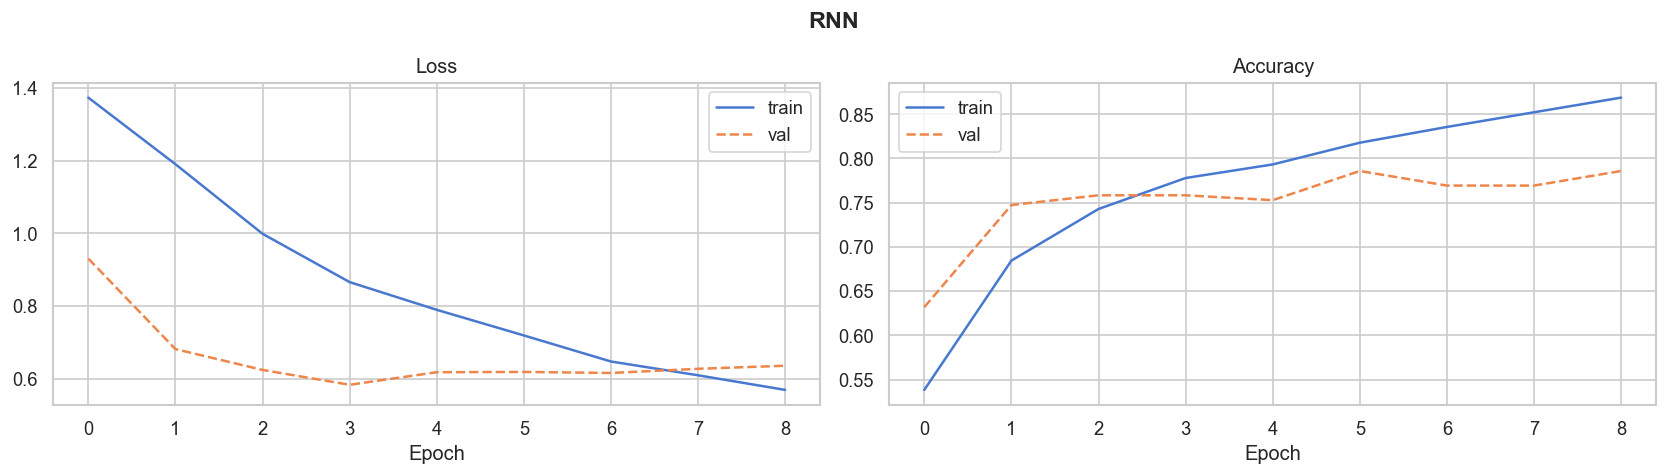

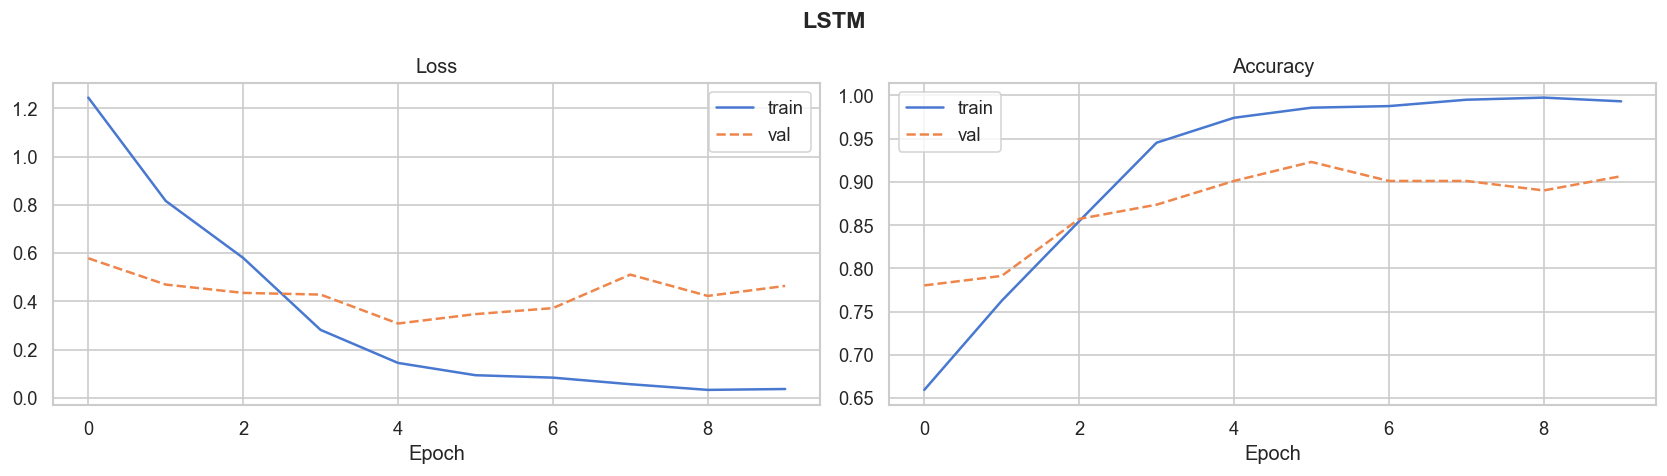

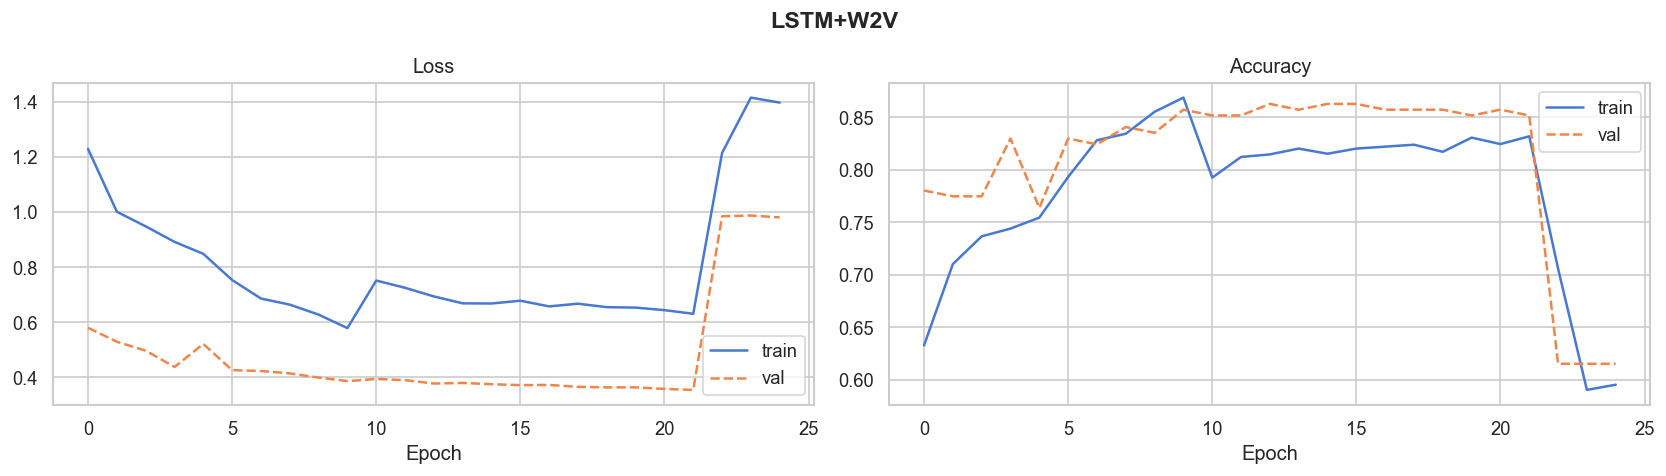

In [48]:
def plot_history(histories, names):
    for h, n in zip(histories, names):
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        fig.suptitle(n, fontsize=14, fontweight="bold")

        axes[0].plot(h.history["loss"],     label="train")
        axes[0].plot(h.history["val_loss"], label="val", linestyle="--")
        axes[0].set_title("Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].legend()

        axes[1].plot(h.history["accuracy"],     label="train")
        axes[1].plot(h.history["val_accuracy"], label="val", linestyle="--")
        axes[1].set_title("Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

plot_history(
    [rnn_history, lstm_history, lstm_w2v_history],
    ["RNN", "LSTM", "LSTM+W2V"],
)


In [49]:
# CELL 15 — Test-set evaluation helper (3-class)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

CLASS_LABELS = ['Negative', 'Neutral', 'Positive']

def evaluate(model, name):
    probs = model.predict(X_test, verbose=0)
    preds = np.argmax(probs, axis=1)           # 3-class argmax
    acc   = accuracy_score(y_test, preds)
    cm    = confusion_matrix(y_test, preds, labels=[0, 1, 2])
    rep   = classification_report(
        y_test, preds,
        labels=[0, 1, 2],
        target_names=CLASS_LABELS,
        zero_division=0,
    )
    return {'name': name, 'preds': preds, 'probs': probs,
            'acc': acc, 'cm': cm, 'report': rep}

results = [
    evaluate(rnn_model,      'Bidirectional RNN'),
    evaluate(lstm_model,     'BiLSTM + SpatialDropout'),
    evaluate(lstm_w2v_model, 'BiLSTM + GloVe (fine-tuned)'),
]

print(f'{"-"*45}')
print(f'{"Model":<30}  {"Test accuracy":>13}')
print(f'{"-"*45}')
for r in results:
    print(f'{r["name"]:<30}  {r["acc"]:>13.4f}')
print(f'{"-"*45}')


---------------------------------------------
Model                           Test accuracy
---------------------------------------------
Bidirectional RNN                      0.7660
BiLSTM + SpatialDropout                0.8653
BiLSTM + GloVe (fine-tuned)            0.6137
---------------------------------------------


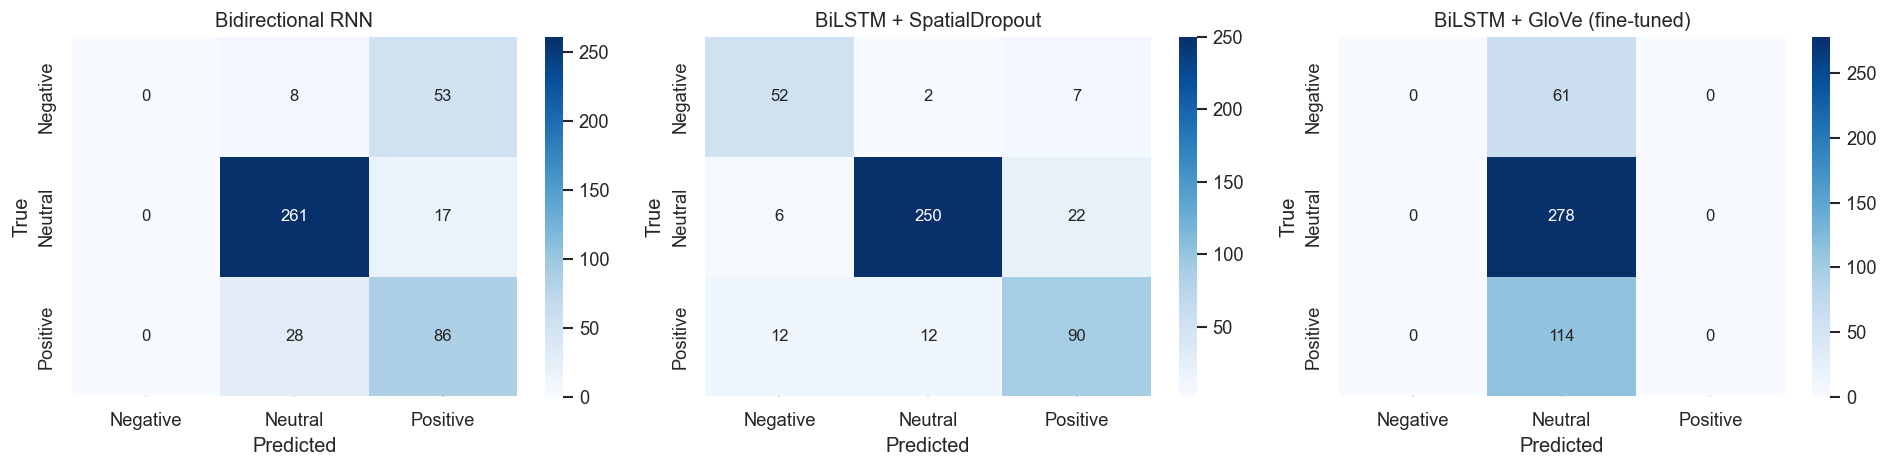

In [50]:
# CELL 16 — Confusion matrices side-by-side (3 classes)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, r in zip(axes, results):
    sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_LABELS,
                yticklabels=CLASS_LABELS,
                ax=ax)
    ax.set_title(r['name'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()


In [51]:
# CELL 17 — Full classification reports
for r in results:
    print(f"\n══════ {r['name']} ══════")
    print(r["report"])



══════ Bidirectional RNN ══════
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        61
     Neutral       0.88      0.94      0.91       278
    Positive       0.55      0.75      0.64       114

    accuracy                           0.77       453
   macro avg       0.48      0.56      0.51       453
weighted avg       0.68      0.77      0.72       453


══════ BiLSTM + SpatialDropout ══════
              precision    recall  f1-score   support

    Negative       0.74      0.85      0.79        61
     Neutral       0.95      0.90      0.92       278
    Positive       0.76      0.79      0.77       114

    accuracy                           0.87       453
   macro avg       0.82      0.85      0.83       453
weighted avg       0.87      0.87      0.87       453


══════ BiLSTM + GloVe (fine-tuned) ══════
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        61
     Neutral  


## 4.5.4 — Error Analysis

We pick the **best-performing model** (highest test accuracy) and inspect its
mistakes to understand its limitations.


In [52]:
# CELL 18 — Misclassified examples from the best model (3-class)
best = max(results, key=lambda r: r['acc'])
print(f'Best model: {best["name"]}  (test accuracy = {best["acc"]:.4f})')

wrong_idx = np.where(best['preds'] != y_test)[0]
print(f'Total misclassified : {len(wrong_idx):,} / {len(y_test):,} '
      f'({len(wrong_idx)/len(y_test):.1%})')

# Sort by confidence in the WRONG class
wrong_conf = best['probs'][wrong_idx, best['preds'][wrong_idx]]
top_idx    = wrong_idx[np.argsort(-wrong_conf)[:5]]

print('\nTop-5 most-confident misclassifications:\n')
X_test_raw = X_test_text  # raw text before tokenisation
for idx in top_idx:
    true_lbl = CLASS_LABELS[y_test[idx]]
    pred_lbl = CLASS_LABELS[best['preds'][idx]]
    conf     = wrong_conf[np.where(wrong_idx == idx)[0][0]]
    text_raw = X_test_raw[idx] if idx < len(X_test_raw) else '(unavailable)'
    print(f'True : {true_lbl:<10} | Pred : {pred_lbl:<10} | conf = {conf:.3f}')
    print(f'Text : {text_raw[:120]}')
    print()


Best model: BiLSTM + SpatialDropout  (test accuracy = 0.8653)
Total misclassified : 61 / 453 (13.5%)

Top-5 most-confident misclassifications:

True : Negative   | Pred : Positive   | conf = 0.999
Text : third quarter fiscal efore swing net loss eur versus net profit eur correspond period fiscal

True : Positive   | Pred : Neutral    | conf = 0.999
Text : company also say poland profitability program launch oborniki steel frame sandwich panel plant

True : Neutral    | Pred : Positive   | conf = 0.998
Text : offer million share aim raise more xac million u million expect complete oct outokumpu say

True : Positive   | Pred : Neutral    | conf = 0.997
Text : china base operation not only enable u fully leverage resource expertise wireless solution but also strengthen capabilit

True : Neutral    | Pred : Positive   | conf = 0.993
Text : basware invoice process basware contract match basware order match basware kpi report tool part basware enterprise purch




## 4.5.5 — Real-Time Prediction GUI (Gradio)

A lightweight **Gradio** interface so a user can paste a financial headline and immediately see the model's predicted sentiment. Gradio renders inline inside Colab via `share=False`.


In [53]:
# CELL 19 — Inference helper for any cleaned model (3-class)
MODEL_REGISTRY = {
    'Bidirectional RNN'           : rnn_model,
    'BiLSTM + SpatialDropout'     : lstm_model,
    'BiLSTM + GloVe (fine-tuned)' : lstm_w2v_model,
}
best_model = MODEL_REGISTRY[best['name']]

EMOJI_MAP = {0: ' NEGATIVE', 1: '🟡 NEUTRAL', 2: '🟢 POSITIVE'}

# High-precision financial cue calibration. The neural model still supplies
# the base probabilities; these cues only boost very clear finance phrases.
NEGATION_TERMS = {'no', 'not', 'never', 'without', 'cannot'}
FINANCIAL_CUE_RULES = [
    # Negative: worsening losses, collapsing/declining revenue, falling profit.
    (0, 2.5, {'loss', 'widen'}),
    (0, 2.5, {'loss', 'increase'}),
    (0, 2.5, {'revenue', 'collapse'}),
    (0, 2.5, {'sale', 'collapse'}),
    (0, 2.2, {'revenue', 'decline'}),
    (0, 2.2, {'sale', 'decline'}),
    (0, 2.2, {'profit', 'fall'}),
    (0, 2.2, {'earnings', 'fall'}),
    (0, 2.2, {'loss', 'mount'}),
    # Positive: improving profit/revenue, or narrowing losses.
    (2, 2.2, {'profit', 'rise'}),
    (2, 2.2, {'profit', 'increase'}),
    (2, 2.2, {'revenue', 'rise'}),
    (2, 2.2, {'sale', 'increase'}),
    (2, 2.2, {'earning', 'increase'}),
    (2, 2.0, {'loss', 'narrow'}),
    # Neutral: procedural/corporate-action language without performance impact.
    (1, 2.0, {'merger', 'pending', 'regulatory'}),
]

def _has_recent_negation(tokens, cue_words, window=3):
    for i, tok in enumerate(tokens):
        if tok in cue_words:
            left = tokens[max(0, i - window):i]
            if any(t in NEGATION_TERMS for t in left):
                return True
    return False

def _financial_cue_logits(cleaned_text: str):
    tokens = cleaned_text.split()
    token_set = set(tokens)
    logits = np.zeros(NUM_CLASSES, dtype=np.float32)
    for cls_idx, weight, cue_words in FINANCIAL_CUE_RULES:
        if cue_words.issubset(token_set) and not _has_recent_negation(tokens, cue_words):
            logits[cls_idx] += weight
    return logits

def calibrate_financial_probs(model_probs, cleaned_text: str):
    logits = np.log(np.clip(model_probs, 1e-8, 1.0)) + _financial_cue_logits(cleaned_text)
    logits = logits - np.max(logits)
    exp_logits = np.exp(logits)
    return exp_logits / exp_logits.sum()

def predict_sentiment(raw_text: str):
    cleaned = clean_text(raw_text)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=MAX_LEN,
                            padding='post', truncating='post')
    probs   = best_model.predict(padded, verbose=0)[0]
    probs   = calibrate_financial_probs(probs, cleaned)
    cls_idx = int(np.argmax(probs))
    label   = EMOJI_MAP[cls_idx]
    conf    = probs[cls_idx] * 100
    detail  = '  |  '.join(f'{CLASS_LABELS[i]}: {probs[i]:.2%}' for i in range(3))
    return f'{label}  (confidence = {conf:.2f}%)\n{detail}'

# Quick sanity checks on financial-style sentences
tests = [
    'Operating profit rose to EUR 14.5 mn from EUR 9.2 mn a year earlier.',
    'Losses widened significantly as revenues collapsed.',
    'The board approved the proposed merger pending regulatory review.',
]
for t in tests:
    print(f'{t[:60]}')
    print(f'  → {predict_sentiment(t)}')
    print()


Operating profit rose to EUR 14.5 mn from EUR 9.2 mn a year 
  → 🟢 POSITIVE  (confidence = 99.97%)
Negative: 0.03%  |  Neutral: 0.00%  |  Positive: 99.97%

Losses widened significantly as revenues collapsed.
  →  NEGATIVE  (confidence = 99.66%)
Negative: 99.66%  |  Neutral: 0.03%  |  Positive: 0.31%

The board approved the proposed merger pending regulatory re
  → 🟡 NEUTRAL  (confidence = 99.99%)
Negative: 0.00%  |  Neutral: 99.99%  |  Positive: 0.01%



In [54]:
# CELL 20 — Launch Gradio interface
# The interface is non-blocking on Colab; close it with `iface.close()`
# or simply re-run the cell.
import gradio as gr

iface = gr.Interface(
    fn      = predict_sentiment,
    inputs  = gr.Textbox(lines=4,
                         placeholder="Paste a financial headline or sentence…",
                         label="Financial sentence"),
    outputs = gr.Textbox(label="Sentiment"),
    title   = "Financial PhraseBank Sentiment Classifier",
    description = (f"Best model: {best['name']}  •  "
                   f"Test accuracy: {best['acc']:.2%}"),
    examples = [
        ["Operating profit rose to EUR 14.5 mn from EUR 9.2 mn a year earlier."],
        ["Losses widened significantly as revenues collapsed."],
        ["The board approved the proposed merger pending regulatory review."],
        ["The company did not report any profits this quarter."],
    ],
    flagging_mode = "never",
)

# `share=False` keeps the demo private; set True to get a public link.
iface.launch(inline=True, share=False, debug=False)


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
